**Website Traffic Analysis**

In [4]:
!pip install kagglehub pandas matplotlib seaborn

import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [5]:
# Download dataset
path = kagglehub.dataset_download("bhanupratapbiswas/website-traffic-analysis")
print("Dataset path:", path)


Dataset path: /kaggle/input/website-traffic-analysis


In [6]:
# Display downloaded files
for root, dirs, files in os.walk(path):
    for file in files:
        print("✅ Found:", os.path.join(root, file))


✅ Found: /kaggle/input/website-traffic-analysis/traffic.csv


In [7]:
import pandas as pd

# Load the dataset
df_web = pd.read_csv('/kaggle/input/website-traffic-analysis/traffic.csv', encoding='ISO-8859-1')

# Preview the first few rows
df_web.head()


,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores MÃ¡s,No Llores MÃ¡s,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,MalÃ©,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [8]:
# Show column names
print(df_web.columns.tolist())

# Convert 'date' column to datetime
df_web['date'] = pd.to_datetime(df_web['date'], errors='coerce')

# Check for nulls
df_web.info()
df_web.isnull().sum()


['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc', 'linkid']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   event    226278 non-null  object        
 1   date     226278 non-null  datetime64[ns]
 2   country  226267 non-null  object        
 3   city     226267 non-null  object        
 4   artist   226241 non-null  object        
 5   album    226273 non-null  object        
 6   track    226273 non-null  object        
 7   isrc     219157 non-null  object        
 8   linkid   226278 non-null  object        
dtypes: datetime64[ns](1), object(8)
memory usage: 15.5+ MB


,0
event,0
date,0
country,11
city,11
artist,37
album,5
track,5
isrc,7121
linkid,0


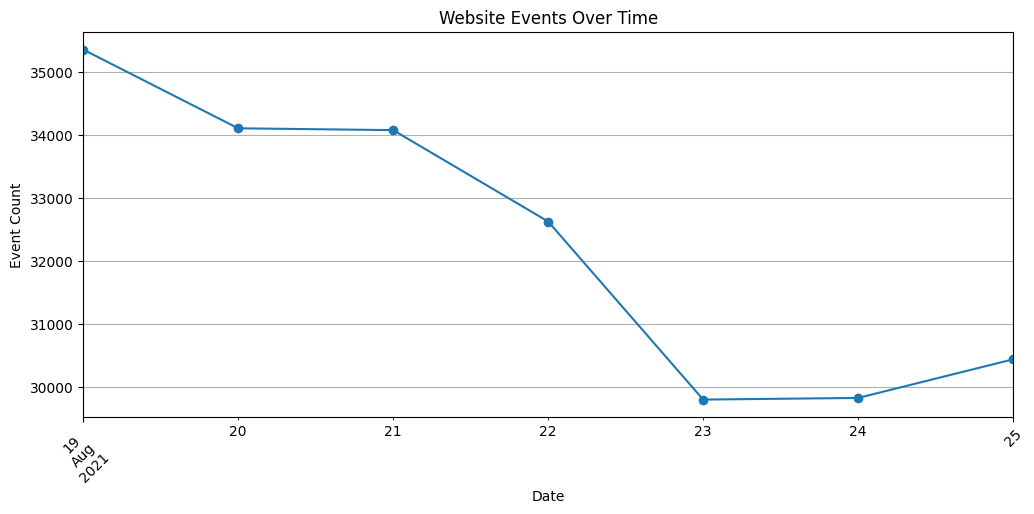

In [9]:
daily_events = df_web.groupby('date').size()

daily_events.plot(figsize=(12, 5), marker='o')
plt.title("Website Events Over Time")
plt.xlabel("Date")
plt.ylabel("Event Count")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


/tmp/ipython-input-10-2599685554.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette='crest')


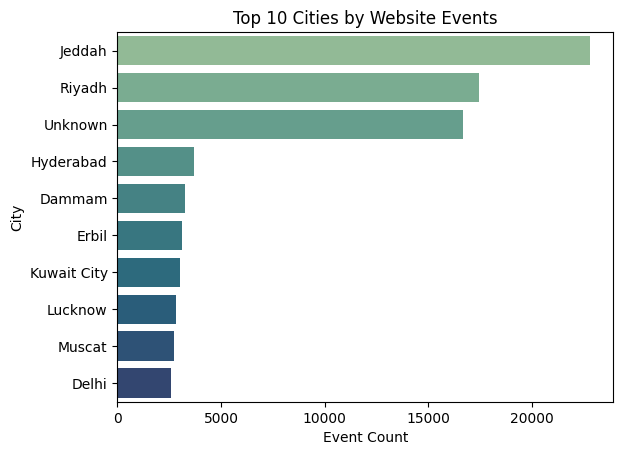

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

top_cities = df_web['city'].value_counts().head(10)

sns.barplot(x=top_cities.values, y=top_cities.index, palette='crest')
plt.title("Top 10 Cities by Website Events")
plt.xlabel("Event Count")
plt.ylabel("City")
plt.show()


/tmp/ipython-input-11-468731130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.values, y=top_artists.index, palette='plasma')


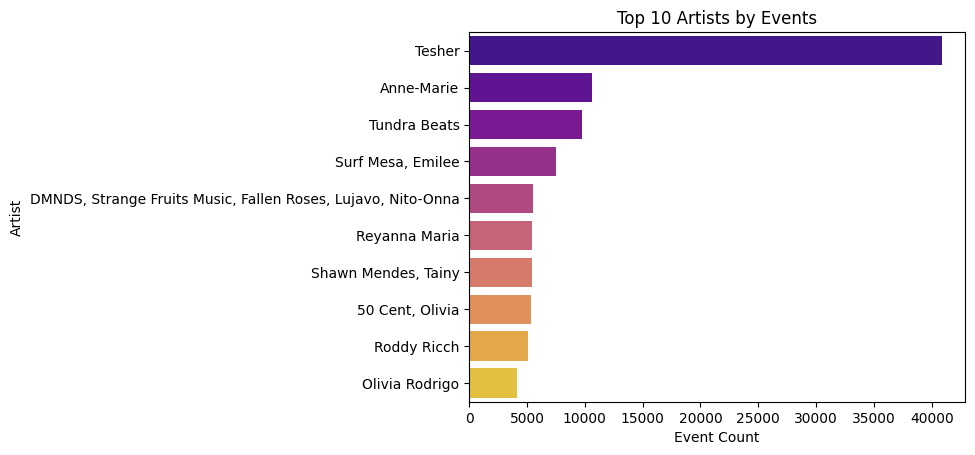

In [11]:
top_artists = df_web['artist'].value_counts().head(10)

sns.barplot(x=top_artists.values, y=top_artists.index, palette='plasma')
plt.title("Top 10 Artists by Events")
plt.xlabel("Event Count")
plt.ylabel("Artist")
plt.show()


/tmp/ipython-input-12-3720264362.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='coolwarm')


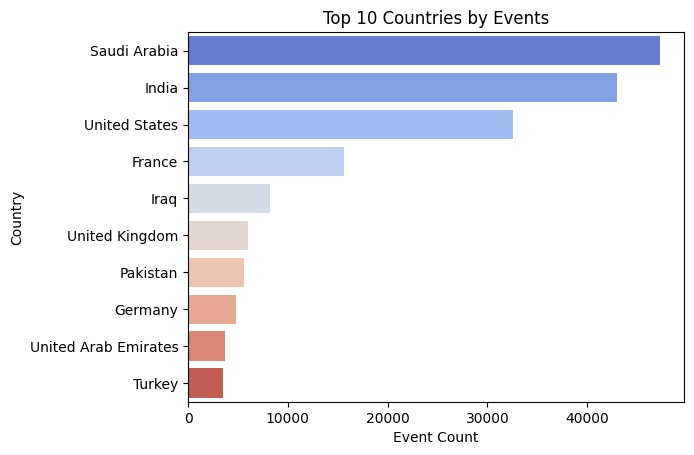

In [12]:
top_countries = df_web['country'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, palette='coolwarm')
plt.title("Top 10 Countries by Events")
plt.xlabel("Event Count")
plt.ylabel("Country")
plt.show()
